<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework4Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/Housing.csv'
data = pd.read_csv('/content/drive/My Drive/Housing.csv')
data.head()

yesno = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for column in yesno:
    data[column] = data[column].map({'yes': 1, 'no': 0})

specs2 = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']


X = data[specs2]
Y = data['price']


Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.20, random_state=50)

scaler = StandardScaler()

Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [100]:
svr_rbf = SVR(kernel='rbf', C=1e6, gamma=0.1)
svr_linear = SVR(kernel='linear', C=1e6)
svr_poly = SVR(kernel='poly', C=1e6, degree=2)

In [101]:
svr_rbf.fit(Xtrain, Ytrain)
svr_linear.fit(Xtrain, Ytrain)
svr_poly.fit(Xtrain, Ytrain)

Yrbf = svr_rbf.predict(Xtest)
Ylinear = svr_linear.predict(Xtest)
Ypoly = svr_poly.predict(Xtest)

In [102]:
models = {'SVR RBF': Yrbf, 'SVR Linear': Ylinear, 'SVR Poly': Ypoly}

results = []

for name, prediction in models.items():

  r2 = r2_score(Ytest, prediction)
  mae = mean_absolute_error(Ytest, prediction)
  mse = mean_squared_error(Ytest, prediction)
  rmse = np.sqrt(mean_squared_error(Ytest, prediction))

  results.append([name, r2, mae, mse, rmse])

results_df = pd.DataFrame(results, columns=['Model', 'R2', 'MAE', 'MSE', 'RMSE'])
results_df

,Model,R2,MAE,MSE,RMSE
0,SVR RBF,0.620421,788960.676707,1.290899e+12,1.136177e+06
1,SVR Linear,0.747069,730320.807366,8.601840e+11,9.274611e+05
2,SVR Poly,0.539792,944497.086012,1.565106e+12,1.251042e+06


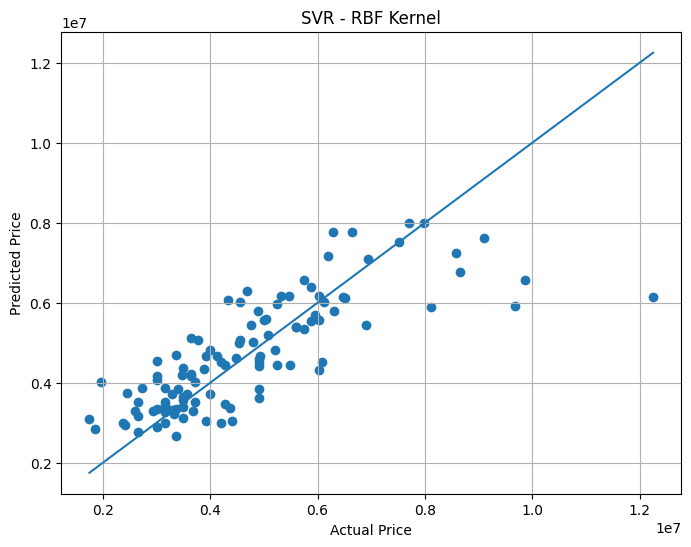

In [107]:
plt.figure(figsize=(8,6))

plt.scatter(Ytest, Yrbf)
minimum = min(Ytest.min(), Yrbf.min())
maximum = max(Ytest.max(), Yrbf.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle='-')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVR - RBF Kernel')
plt.grid(True)

plt.show()



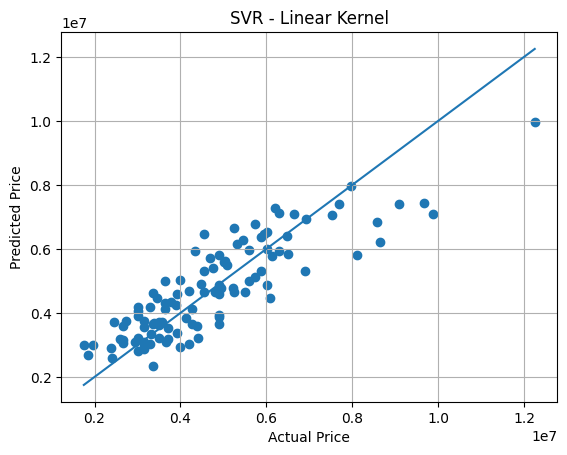

In [104]:
plt.scatter(Ytest, Ylinear)
minimum = min(Ytest.min(), Ylinear.min())
maximum = max(Ytest.max(), Ylinear.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle='-')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVR - Linear Kernel')
plt.grid(True)

plt.show()

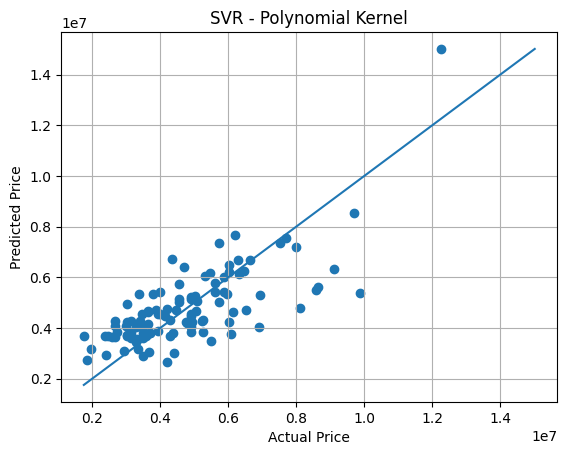

In [105]:
plt.scatter(Ytest, Ypoly)
minimum = min(Ytest.min(), Ypoly.min())
maximum = max(Ytest.max(), Ypoly.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle='-')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVR - Polynomial Kernel')
plt.grid(True)

plt.show()

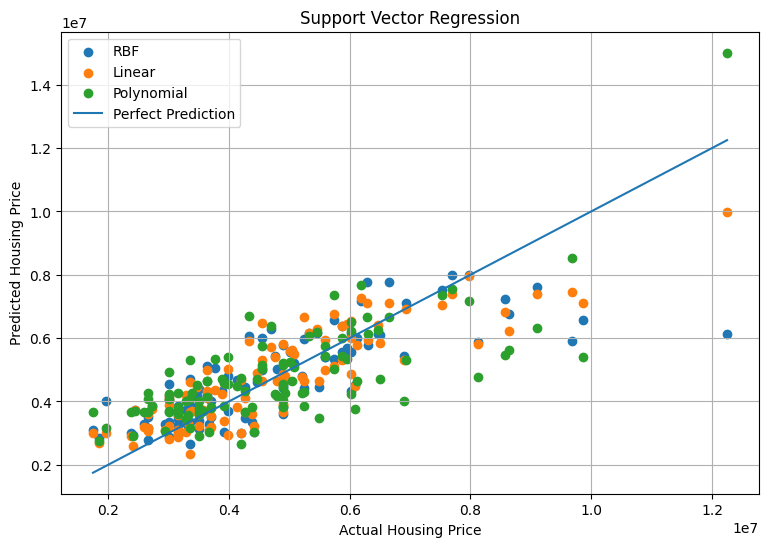

In [108]:
plt.figure(figsize=(9, 6))

plt.scatter(Ytest, Yrbf, label='RBF')

plt.scatter(Ytest, Ylinear, label='Linear')

plt.scatter(Ytest, Ypoly, label='Polynomial')


minimum = Ytest.min()
maximum = Ytest.max()

plt.plot([minimum, maximum], [minimum, maximum], linestyle='-',label='Perfect Prediction')

plt.xlabel('Actual Housing Price')
plt.ylabel('Predicted Housing Price')
plt.title('Support Vector Regression')

plt.legend()
plt.grid(True)

plt.show()